In [33]:
import pickle
import numpy as np
from matplotlib import pyplot as plt
from tqdm.notebook import tqdm
import csv
from mpl_toolkits.axes_grid1 import host_subplot
from matplotlib import rcParams

from defs import *

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [34]:
# list of files and directories
home_dir = '../../../'
raw_dir = home_dir + 'data/kagome-02.26.2022-center/raw/real_space/'
processed_dir = home_dir + 'data/kagome-02.26.2022-center/preprocessed/real_space/'
sim_raw_dir = home_dir + 'data/kagome-02.26.2022-center-sim/raw/'
sim_processed_dir = home_dir + 'data/kagome-02.26.2022-center-sim/preprocessed/'
out_dir = home_dir + "output/paper_upload/"


# Plot experimental data

In [35]:
# Pre-process the experimental data

data = pickle.load(open(raw_dir+os.listdir(raw_dir)[0], 'rb'))
frequencies = data[:,0]

preprocess_chirp(data_dir = raw_dir, 
                 frequencies = frequencies, 
                 targetfile = processed_dir, 
                 title = 'scppos_', setno = 0)


Found 164 records
Preprocessing complete!


In [36]:
# Define shared parameters for plotting

preamp_gain = 4.731513 #13.5 dB at minimum gain
mic_gain = 0.02 #0.02V/Pa 

x_unit = 10*np.sqrt(3)/4
y_unit = 7.5
radius = 3.5

## Flat band data

In [37]:
freq_fb = 14.4
fn = processed_dir + f"_{int(freq_fb*1e3)}.0_0.pkl"
fb_exp_data = pickle.load(open(fn, 'rb'))

max_idx_fb = np.argmax(fb_exp_data[:, 2])
phase_ref_fb = fb_exp_data[max_idx_fb, 3]
value_fb = fb_exp_data[:, 2] /preamp_gain/mic_gain * np.cos(np.deg2rad((fb_exp_data[:, 3] - phase_ref_fb)))
max_amp_flat = np.max(fb_exp_data[:, 2] /preamp_gain/mic_gain)

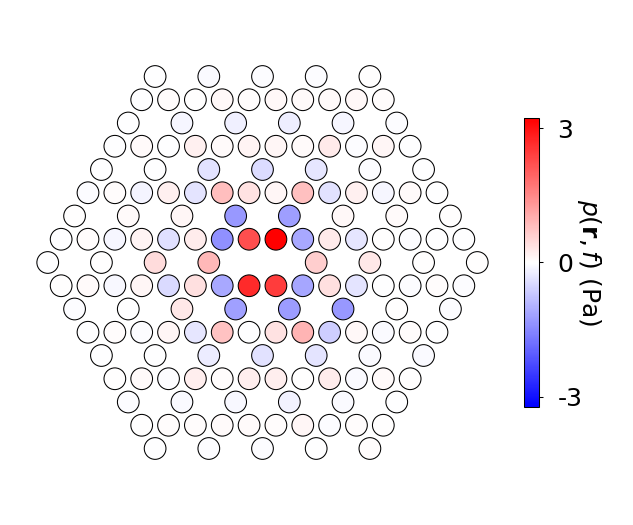

In [38]:
fig, ax = real_space_plot(
    x_coords=fb_exp_data[:, 0] * x_unit,
    y_coords=fb_exp_data[:, 1] * y_unit,
    value= value_fb,
    max_amp=max_amp_flat,
    radius=radius,
    out_path=out_dir + f"amplitude_plot_{freq_fb}kHz.pdf",
)

## Dispersive band data

In [39]:
freq_db = 4
fn = processed_dir + f"_{int(freq_db*1e3)}.0_0.pkl"
db_exp_data = pickle.load(open(fn, 'rb'))

max_idx_db = np.argmax(db_exp_data[:, 2])
phase_ref_db = db_exp_data[max_idx_db, 3]
value_db = db_exp_data[:, 2] /preamp_gain/mic_gain * np.cos(np.deg2rad((db_exp_data[:, 3] - phase_ref_db)))

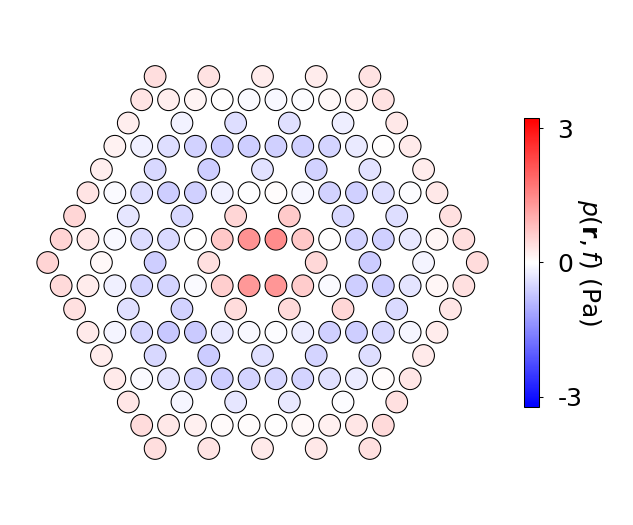

In [40]:
fig, ax = real_space_plot(
    x_coords=db_exp_data[:, 0] * x_unit,
    y_coords=db_exp_data[:, 1] * y_unit,
    value= value_db,
    max_amp=max_amp_flat,
    radius=radius,
    out_path=out_dir + f"amplitude_plot_{freq_db}kHz.pdf",
)

# Simulation data plotting

In [41]:
# shared parameters

sim_to_exp_scale = 1e3

## Pre-processing

In [42]:
setno = 0
sim_raw_fn = "4_14kHz_real_space_new.csv"
headerNum = 5

with open(sim_raw_dir+sim_raw_fn, newline='') as csvfile:
    reader = csv.reader(csvfile, delimiter=',')

    for i in range(headerNum):
        next(reader)
        
    for i,row in tqdm(enumerate(reader)):
        real_data = []

        if i==0:
            datapoint_num = int((len(row)-1)/4)
        
        print("Processing frequency: ", row[0], "kHz")
        for j in range(1, datapoint_num+1, 1):
            currentData = [float(row[j+datapoint_num*2]), float(row[j+datapoint_num*3]), float(row[j]), np.rad2deg(float(row[j+datapoint_num]))]
            real_data.append(currentData)

        np.array(real_data).dump(sim_processed_dir + '_' + str(float(row[0])*1000) + '_' + str(setno) + '.pkl')
        

0it [00:00, ?it/s]

Processing frequency:  4 kHz
Processing frequency:  14.4 kHz


## Flat band data

In [43]:
fn_fb_sim = sim_processed_dir + f"_{int(freq_fb*1e3)}.0_0.pkl"
fb_sim_data = central_cut(np.array(pickle.load(open(fn_fb_sim, 'rb'))), source_pos=(2*x_unit/sim_to_exp_scale, 0), edge_relax=radius*0.2/sim_to_exp_scale)

max_idx_fb_sim = np.argmax(fb_sim_data[:, 2])
max_amp_flat_sim = np.max(fb_sim_data[:, 2])
phase_ref_fb_sim = fb_sim_data[max_idx_fb_sim, 3]
value_fb_sim = fb_sim_data[:, 2] * np.cos(np.deg2rad((fb_sim_data[:, 3] - phase_ref_fb_sim)))

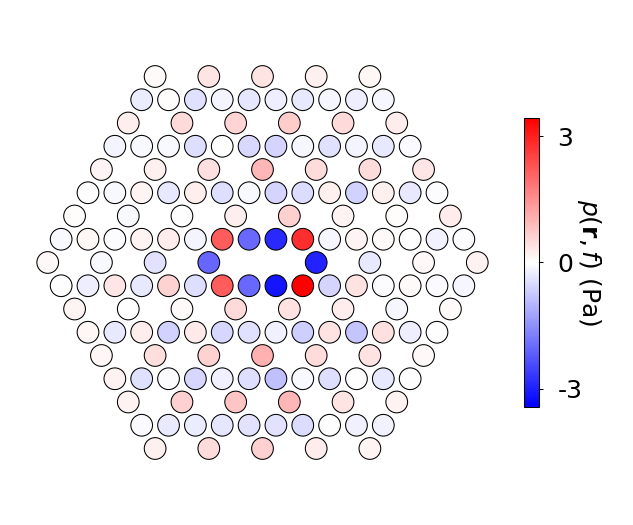

In [44]:
fig, ax = real_space_plot(
    x_coords=fb_sim_data[:, 0]*sim_to_exp_scale,
    y_coords=fb_sim_data[:, 1]*sim_to_exp_scale,
    value= value_fb_sim,
    max_amp=max_amp_flat_sim,
    radius=radius,
    out_path=out_dir + f"amplitude_plot_{freq_fb}kHz_sim.pdf",
)

## Dispersive band data

In [45]:
fn_db_sim = sim_processed_dir + f"_{int(freq_db*1e3)}.0_0.pkl"
db_sim_data = central_cut(np.array(pickle.load(open(fn_db_sim, 'rb'))), source_pos=(2*x_unit/sim_to_exp_scale, 0), edge_relax=radius*0.2/sim_to_exp_scale)

max_idx_db_sim = np.argmax(db_sim_data[:, 2])
phase_ref_db_sim = db_sim_data[max_idx_db_sim, 3]
value_db_sim = db_sim_data[:, 2] *np.cos(np.deg2rad((db_sim_data[:, 3] - phase_ref_db_sim)))

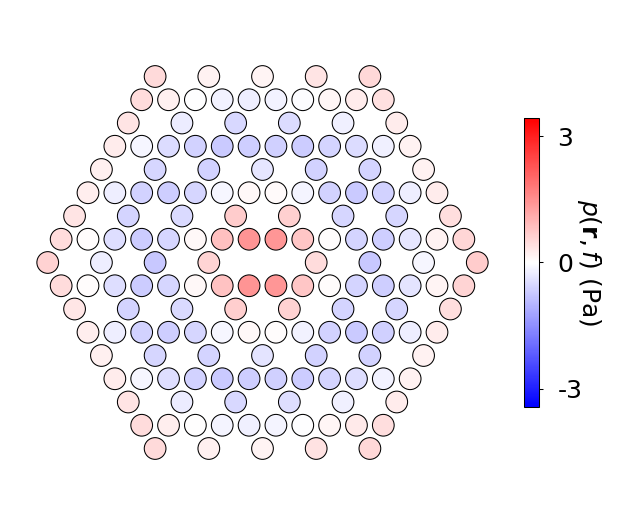

In [46]:
fig, ax = real_space_plot(
    x_coords=db_sim_data[:, 0]*sim_to_exp_scale,
    y_coords=db_sim_data[:, 1]*sim_to_exp_scale,
    value= value_db_sim,
    max_amp=max_amp_flat_sim,
    radius=radius,
    out_path=out_dir + f"amplitude_plot_{freq_db}kHz_sim.pdf",
)